## Import Libraries

In [98]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import os
import copy
%matplotlib inline

## Class with all the user defined functions

In [99]:
class Utilities: 
    def interpolate(self, data = None, method='linear', column='Power'):
        if data is None:
                print("Data not found in method: interpolate")
        if isinstance(data, pd.DataFrame):
            series = data[column]
        elif isinstance(data, np.ndarray):
             series = data
        else:
            print("No supported type found. Please use either a dataframe or a series to interpolate.")
            return None
        if method=='bfill':
            series = series.bfill()
        elif method=='ffill':
            series = series.ffill()
        else:
            series = series.interpolate(method=method)
        if isinstance(data, pd.DataFrame):
            data[column] = series
        return data
    
    def findTrend(self, series, order):
        coef = np.polyfit(np.arange(len(series)), series.values.ravel(), order)
        poly_mdl = np.poly1d(coef)
        trend = pd.Series(data=poly_mdl(np.arange(len(series))))
        return trend

    def detrendData(self, data, order, column='Power'):
        interpolated_data = self.interpolate(data.copy(), method='cubic', column=column)
        interpolated_data = self.interpolate(interpolated_data, method='bfill', column=column)
        interpolated_data = self.interpolate(interpolated_data, method='ffill', column=column)
        trend = self.findTrend(interpolated_data[column], order)
        detrended = data[column].values - trend
        detrended_data = data.copy()
        detrended_data[column] = detrended.values
        detrended_data.index = data.index
        return trend, detrended_data
    
    def timeToColumn(self, time):
        word = 'Power(t'
        if time>0:
            word +='+'
        word += str(time)+')'
        return word
    
    def timeSetToColumns(self, times):
        columns = []
        for time in times:
            if isinstance(time, str):
                columns.append(time)
                continue
            column = self.timeToColumn(time)
            columns.append(column)
        return columns
    
    def doPowerShifts(self, data, values, column='Power'):
        for val in values:
            new_column = self.timeToColumn(val)
            data[new_column] = data[column].shift(val*(-1))
        return data
    
    def findSubs(self, arr, index, subs, allsubs): 
        if index == len(arr): 
            if len(subs) >= 1: 
                allsubs.append(subs)
        else: 
            self.findSubs(arr, index + 1, subs, allsubs) 
            self.findSubs(arr, index + 1, subs+[arr[index]], allsubs)

    def generateCombinations(self, hourlyDifference, seasonal):
        daily_subs = []
        seasonal_subs = []

        self.findSubs(hourlyDifference, 0, [], daily_subs)
        self.findSubs(seasonal, 0, [], seasonal_subs)

        all_subs = []
        for daily_sub in daily_subs:
            for seasonal_sub in seasonal_subs:
                l = daily_sub+seasonal_sub
                all_subs.append(l)
        return all_subs
    
    def exportData(self, data, folder_path, file_prefix, rename_index_to = 'Time', power_column = 'Power'):
        data.reset_index(inplace=True)
        data.rename(columns={'index':rename_index_to}, inplace=True)
        data[power_column].fillna('NR', inplace=True)
        data[rename_index_to] = pd.to_datetime(data[rename_index_to]) 

        for date, group in data.groupby(data[rename_index_to].dt.date):
            file_name = f"{folder_path}/{file_prefix}_{date}.xlsx" 
            group.to_excel(file_name, index=False, engine='openpyxl')

    def predDataSplit(self, trimmed_data, train_data, input_columns, output_column='Power'):
        X_pred = trimmed_data.loc[:, input_columns].values
        X = train_data.loc[:, input_columns].values
        Y = train_data[output_column].values
        X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1)
        return X_train, X_test, Y_train, Y_test, X_pred

    def trimData(self, data, input_columns, output_column='Power', predicted_column='PredictedPower'):
        trimmed_data = data.dropna(subset=input_columns)
        train_data = trimmed_data.dropna(subset=input_columns+[output_column])
        trimmed_data = trimmed_data[trimmed_data[predicted_column].isna()]
        return trimmed_data, train_data

    def predictValues(self, X_train, X_test, Y_train, Y_test, X_pred):
        
        model = LinearRegression()
        model.fit(X_train, Y_train)
        score = model.score(X_test, Y_test)
        Y_pred = model.predict(X_pred)
        return Y_pred, score

    def fillValues(self, data, time_instants, values, predicted_column='PredictedPower'):
        count = 0
        if len(time_instants)!=len(values):
            print("Length mismatch for filling values")
            return None
        for time, value in zip(time_instants, values):
            data.loc[time, predicted_column] = value
            count+=1
        return data, count

In [100]:
utilities = Utilities()

## Class with all the uder defined functions for Loading data

In [ ]:
class DataLoadFunctions:
    data = None

    __power_key = 'Power'

    def __init__(self, data = None):
        self.utilities = Utilities()
        if data is not None:
            self.data = data
        
    def __update_corrupt_power(self, row):
        if (type(row[self.__power_key])==str) and ',' in row[self.__power_key]:
            return float(row[self.__power_key].replace(',', '.'))
        else:
            return row[self.__power_key]
        
        
    def preprocess(self, data = None, interpolate = False, update=False):
        if data is None:
            if self.data is None:
                print("Data not found in method: preprocess")
                return None
            data = self.data.copy()
        data.index = pd.to_datetime(data.index)

        data[self.__power_key] = data.apply(self.__update_corrupt_power, axis=1)
        data[self.__power_key] = pd.to_numeric(data[self.__power_key], errors='coerce')

        data = data.sort_index()

        if interpolate:
            data = self.utilities.interpolate(data)
            data = self.utilities.interpolate(data, method='bfill')
            data = self.utilities.interpolate(data, method='ffill')
        if update:
            self.data = data
        return data
    
    def setTimeAsIndex(self, data, time_header='Time'):
        data = data.drop_duplicates(subset=[time_header])
        data = data.set_index(time_header, drop=True)
        data.index.name = None
        return data
        
    def loadData(self, file_list, interpolate = False, time_header='Time', power_header='Power'):
        data = pd.DataFrame()
        for file_path in file_list:
            target_columns = [time_header, power_header]
            header_row = None
            
            df = pd.read_excel(file_path, header=None)
            for i, row in enumerate(df.values):
                row_lower = [str(cell).lower() for cell in row]  
                if all(col_name.lower() in row_lower for col_name in target_columns):
                    header_row = i
                    break  

            if header_row is not None:
                df.columns = df.iloc[header_row]
                df = df.iloc[header_row+1:][target_columns]
                data = pd.concat([data, df], ignore_index=True)
            else:
                print("Header row not found in the file:", file_path)
        data = self.setTimeAsIndex(data, time_header)
        data.rename(columns = {power_header:self.__power_key}, inplace=True)
        data = self.preprocess(data, interpolate)
        self.data = data
        return data
    
    def loadAllData(self, folder_path, interpolate = False, time_header='Time', power_header='Power', start_time=None, end_time=None):
        file_list = []
        if os.path.exists(folder_path) and os.path.isdir(folder_path):
            for root, dirs, files in os.walk(folder_path):
                for file in files:
                    file_path = os.path.join(root, file)
                    file_list.append(file_path)
        data = self.loadData(file_list, interpolate, time_header, power_header)
        if start_time is not None and end_time is not None:
            data = self.getData(start_time, end_time, data)
            self.setData(data)
        return data
    
    def getData(self, start_time = None, end_time = None, data = None, use_month_key = False):
        if data is None:
            if self.data is None:
                print("Data not found in method: getData")
                return None
            data = self.data.copy()
        if start_time is None and end_time is None:
            return data
        start_time = pd.to_datetime(start_time)
        end_time = pd.to_datetime(end_time)
        if use_month_key == True:
            mask = (data.index >= start_time) & (data.index <= end_time)
        else:
            mask = (data.index > start_time) & (data.index < end_time)
        data = data.loc[mask]
        return data
    
    def setData(self, data):
        if data is not None:
            self.data = data
    

## Loading all the Data

In [102]:
apdcl_import = DataLoadFunctions()
pv_gen = DataLoadFunctions()
weather = DataLoadFunctions()

In [ ]:
apdcl_import_data = apdcl_import.loadAllData('apdcl_import_data/', 
                                             power_header='MW', 
                                             start_time='2023-03-01', 
                                             end_time='2023-12-31')
pv_gen_data = pv_gen.loadAllData('pv_gen_data/', 
                                 time_header='x1', 
                                 power_header='ActivePower', 
                                 start_time='2023-03-01', 
                                 end_time='2023-12-31')
weather_data = weather.loadAllData('weather_data/', 
                                   power_header='Temperature', 
                                   start_time='2023-03-01', 
                                   end_time='2023-12-31')

c:\Users\ipsit\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\indexes\base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


### Making all the data compatible

In [ ]:
apdcl_import_data.loc[apdcl_import_data['Power'] > 10, 'Power'] = None
pv_gen_data = pv_gen_data[pv_gen_data['Power'] > 0]
pv_gen_data.loc[:,'Power'] = pv_gen_data['Power']/1000
weather_data.rename(columns={'Power':'Temperature'}, inplace=True)

## Merging the data

In [ ]:
demand_data = pd.merge(apdcl_import_data, 
                       pv_gen_data, 
                       suffixes=('_import', '_solar'),
                       left_index=True, 
                       right_index=True, 
                       how='left')
demand_data['Power_solar'].fillna(0, inplace=True)
demand_data['Power'] = demand_data['Power_import'] + 1.9*demand_data['Power_solar']
demand_data = demand_data.drop(columns=['Power_import','Power_solar'])
demand_data = demand_data[~demand_data.index.duplicated(keep='first')]
demand_data = demand_data.sort_index()

demand_data = pd.merge(demand_data, 
                       weather_data, 
                       left_index=True, 
                       right_index=True, 
                       how='left')
demand_data.head()

C:\Users\ipsit\AppData\Local\Temp\ipykernel_23264\2501976424.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  demand_data['Power_solar'].fillna(0, inplace=True)


,Power,Temperature
2023-03-01 01:00:00,3.1,NaN
2023-03-01 02:00:00,3.1,NaN
2023-03-01 03:00:00,2.5,22.22
2023-03-01 04:00:00,2.5,21.11
2023-03-01 05:00:00,2.5,20.00


## Detrending the data

In [ ]:
trend_power, detrended_demand_data = utilities.detrendData(demand_data, 
                                                           order=15, 
                                                           column='Power')
trend_temperature, detrended_demand_data = utilities.detrendData(detrended_demand_data, 
                                                                 order=15, 
                                                                 column='Temperature')
detrended_demand_data.head(5)

,Power,Temperature
2023-03-01 01:00:00,-17.750173,NaN
2023-03-01 02:00:00,-16.817054,NaN
2023-03-01 03:00:00,-16.507673,-2.478516
2023-03-01 04:00:00,-15.621648,-3.619915
2023-03-01 05:00:00,-14.758604,-4.761397


In [107]:
detrended_demand_data['abs_Temperature'] = abs(detrended_demand_data['Temperature'])
detrended_demand_data['Temperature_2'] = detrended_demand_data['Temperature']*detrended_demand_data['abs_Temperature']
detrended_demand_data.drop(columns=['abs_Temperature'], inplace=True)
detrended_demand_data.head(5)

,Power,Temperature,Temperature_2
2023-03-01 01:00:00,-17.750173,NaN,NaN
2023-03-01 02:00:00,-16.817054,NaN,NaN
2023-03-01 03:00:00,-16.507673,-2.478516,-6.143040
2023-03-01 04:00:00,-15.621648,-3.619915,-13.103786
2023-03-01 05:00:00,-14.758604,-4.761397,-22.670898


## Function for data imputation

In [ ]:
def impute(data, hourlyDifference, dailyDifference):
    results = []

    time_sets = utilities.generateCombinations(hourlyDifference, dailyDifference)
    time_sets = copy.deepcopy(time_sets)+copy.deepcopy(time_sets)+copy.deepcopy(time_sets)
    for i in range(len(time_sets)//2):
        time_sets[i].append('Temperature')
        time_sets[i].append('Temperature_2')
    
    for time_set in time_sets:
        if len(time_set)==0:
            continue
        input_columns = utilities.timeSetToColumns(time_set)
        
        trimmed_data, train_data = utilities.trimData(data, input_columns)
        X_train, X_test, Y_train, Y_test, X_pred = utilities.predDataSplit(trimmed_data, 
                                                                           train_data, 
                                                                           input_columns)
        if X_train.shape[0]<1000 or X_pred.shape[0]<1:
            continue
        Y_pred, score = utilities.predictValues(X_train, X_test, Y_train, Y_test, X_pred)

        time_instants = trimmed_data.index
        if(score>0.85):
            results.append((score, time_instants, Y_pred, input_columns))
        
    results.sort()
    results.reverse()
    
    filled = 0
    for result in results:
        data, count = utilities.fillValues(data, result[1], result[2])
        filled+=count 
    return filled

In [109]:
hourlyDifference = [1,-1,2,-2]
dailyDifference = [24,-24,48,-48,-72,72]
detrended_demand_data['PredictedPower'] = [np.nan]*detrended_demand_data.shape[0]
while detrended_demand_data['Power'].isna().sum()>0:
    utilities.doPowerShifts(detrended_demand_data, hourlyDifference+dailyDifference)
    impute(detrended_demand_data, hourlyDifference, dailyDifference)
    detrended_demand_data['Power'] = detrended_demand_data['PredictedPower']

In [110]:
predicted_values = detrended_demand_data['PredictedPower'].values+trend_power
predicted_data = pd.DataFrame({'Power':demand_data['Power'].values, 'PredictedPower':predicted_values})
predicted_data.index = detrended_demand_data.index

## Visualising the Data

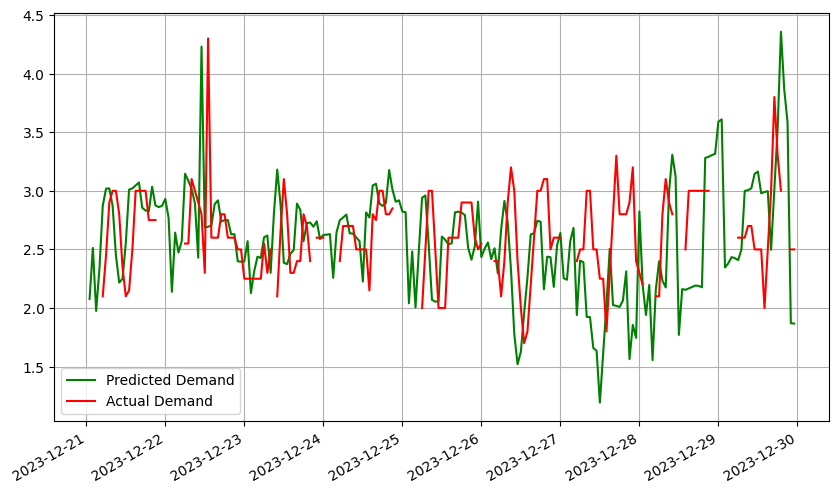

In [111]:
start_time_ana = pd.to_datetime('2023-12-21')
end_time_ana = pd.to_datetime('2023-12-30')
filtered_data = predicted_data[(predicted_data.index>start_time_ana) & (predicted_data.index<end_time_ana)]

fig, ax1 = plt.subplots(figsize=(10, 6))
plt.plot(filtered_data.index, filtered_data['PredictedPower'], color='green', label='Predicted Demand')
plt.plot(filtered_data.index, filtered_data['Power'], color='red', label='Actual Demand')
fig.autofmt_xdate()
plt.legend()
plt.grid(True)
plt.show() 

## Checking the r2-score

In [112]:
df = predicted_data.dropna(subset=['Power', 'PredictedPower'])
r2 = r2_score(df['Power'], df['PredictedPower'])
print("r2-score:", r2)

r2-score: 0.7843538071790742


## Exporting the data

In [ ]:
final_data = predicted_data.drop(columns=['Power'])
final_data.rename(columns={'PredictedPower':'Power'}, inplace = True)
utilities.exportData(data = final_data, folder_path = 'imputed_data', file_prefix='demand')

C:\Users\ipsit\AppData\Local\Temp\ipykernel_23264\3379981643.py:87: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[power_column].fillna('NR', inplace=True)
